# Example 1: Propagating an ELFO Orbit

This example initializes a lunar Elliptical Frozen Orbit (ELFO) from classical
orbital elements (COE) defined in the Moon-centered **Orbital Plane (OP)** frame,
converts the state to the **Moon-Centered Inertial (MCI)** frame, propagates it for
30 days with full N-body dynamics and Solar Radiation Pressure (SRP), and
visualizes both the 3-D trajectory and the evolution of osculating orbital elements.

The OP frame is centered at the Moon and rotated to match the instantaneous orbital
plane of the Earth around the Moon, making it convenient for defining orbits whose
long-term stability is governed by Earth's third-body perturbation (Ely, 2005).
The canonical ELFO parameters (`a`, `e`, `i`, `ω`) below are taken from that paper.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import plotly.graph_objects as go

import pylupnt as pnt

[00.00][PyLuPNT] Initializing


## Epoch

LuPNT propagates using International Atomic Time (TAI). We use the same
reference epoch as the original ELFO study.

In [2]:
t0 = pnt.gregorian_to_time(2009, 7, 15, 1, 0, 0)  # [s] TDB
print(f"Epoch: {pnt.time_to_gregorian_string(t0)} TDB")

Epoch: 2009-07-15T01:00:00.000 TDB


## Initial state: ELFO in classical orbital elements (OP frame)

COE layout: `[a, e, i, RAAN, ω, M]` with angles in radians and `a` in metres.
`pnt.RAD` converts degrees to radians.

In [3]:
a    = 6541.4e3        # [m]   semi-major axis
e    = 0.6             # [-]   eccentricity
i    = 56.2 * pnt.RAD  # [rad] inclination
raan = 0.0 * pnt.RAD   # [rad] right ascension of the ascending node
w    = 90.0 * pnt.RAD  # [rad] argument of perigee
M0   = 0.0 * pnt.RAD   # [rad] mean anomaly

coe0_op = np.array([a, e, i, raan, w, M0])

period = pnt.get_orbital_period(a, pnt.GM_MOON)  # [s]
print(f"Orbital period: {period / pnt.SECS_HOUR:.2f} hours")

Orbital period: 13.19 hours


## Convert to Cartesian state and from OP to MCI

`classical_to_cart` converts COE → Cartesian in the same frame (OP here).
`convert_frame` then rotates from `MOON_OP` to `MOON_CI` at the given epoch.

In [4]:
rv0_op  = pnt.classical_to_cart(coe0_op, pnt.GM_MOON)              # [m, m/s] in OP
rv0_mci = pnt.convert_frame(t0, rv0_op, pnt.MOON_OP, pnt.MOON_CI)  # [m, m/s] in MCI

print(f"r0 (OP):  {rv0_op[:3] / 1e3} km")
print(f"r0 (MCI): {rv0_mci[:3] / 1e3} km")

r0 (OP):  [1.60218091e-13 1.45558086e+03 2.17432072e+03] km
r0 (MCI): [1076.81196343 -334.3332965  2361.16146756] km


## Force model

We use `NBodyDynamics` with the following forces:

| Force | Model | Note |
|---|---|---|
| Moon gravity | 2×2 spherical harmonics | `create_body(MOON, n=2, m=2)` includes J₂ and C₂₂ |
| Earth third-body | Point mass | dominant long-period perturbation driving e–ω libration |
| Sun third-body | Point mass | secondary long-period perturbation |
| Solar radiation pressure | Cannon-ball | C_R = 1.8, A = 0.02 m², m = 10 kg |

`set_units(pnt.SI_UNITS)` tells LuPNT the state vector is in metres/seconds,
mirroring the `Units::SI` flag in the C++ API.

The integrator is **RKF45** (Runge-Kutta-Fehlberg 4/5) with adaptive step size:

| Parameter | Value | Meaning |
|---|---|---|
| `reltol` | 1×10⁻¹⁰ | max relative error per step |
| `abstol` | 1×10⁻⁶ m | absolute floor (≈ 1 µm in position) |

In [5]:
dyn = pnt.NBodyDynamics()
dyn.set_frame(pnt.MOON_CI)
dyn.set_units(pnt.SI_UNITS)               # states in metres / seconds

dyn.add_body(pnt.create_body(pnt.MOON, 2, 2))  # Moon gravity, 2×2 spherical harmonics
dyn.add_body(pnt.create_body(pnt.EARTH))        # Earth third-body
dyn.add_body(pnt.create_body(pnt.SUN))          # Sun third-body + SRP source

dyn.set_srp_coeff(1.8, 0.02, 10.0)       # C_R, area [m²], mass [kg]

dyn.set_integrator(pnt.IntegratorType.RKF45)
params = pnt.IntegratorParams()
params.reltol = 1e-10  # relative tolerance
params.abstol = 1e-6   # absolute tolerance [m] — 1 µm position floor
dyn.set_integrator_params(params)

## Propagate for 2 years

We analyze the long term stability of the orbit by propagating the orbit for 2 years.

In [6]:
sim_days = 30 * 24
dt_out   = 30 * pnt.SECS_MINUTE  # [s] output cadence

tspan = np.arange(0, sim_days * pnt.SECS_DAY + dt_out, dt_out)  # relative [s]
tfs   = t0 + tspan                                                # absolute TAI [s]

rv_mci = dyn.propagate(rv0_mci, tfs)  # [N×6] in metres / metres·s⁻¹
t_days = tspan / pnt.SECS_DAY

print(f"Propagated {sim_days} days — {len(tfs)} output steps")

Propagated 720 days — 34561 output steps


## 3-D trajectory (first 2 orbital periods)

We plot only the first two revolutions (~26 h) to keep the figure readable.

In [7]:
n_plot = int(np.ceil(2 * period / dt_out)) + 1  # two orbital periods

fig = go.Figure()
pnt.plot.plot_body(fig, pnt.MOON)
pnt.plot.plot_orbits(fig, rv_mci[:n_plot], t=0)
pnt.plot.set_view(fig, azimuth=-35, elevation=10, zoom=3)
fig.update_layout(
    width=560, height=560,
    title=f"ELFO trajectory — first 2 orbits (~{2 * period / pnt.SECS_HOUR:.1f} h), MCI frame",
)
fig.show()

## Osculating orbital elements (OP frame)

Propagation is done in MCI, but the ELFO frozen point `(e=0.6, ω=90°)` is defined
in the **Orbital Plane (OP)** frame, which co-rotates with the Earth–Moon orbital
plane.  We therefore convert each state back to OP before extracting COE.
In MCI the ω and RAAN would drift continuously, obscuring the frozen-orbit
character of the trajectory.

In [8]:
# Convert each MCI state to the OP frame, then extract osculating COE.
rv_op = np.array([pnt.convert_frame(tfs[k], rv_mci[k], pnt.MOON_CI, pnt.MOON_OP)
                  for k in range(len(tfs))])
coe = np.array([pnt.cart_to_classical(rv_op[k], pnt.GM_MOON) for k in range(len(tfs))])
# columns: [a, e, i, RAAN, ω, M]  —  angles in radians, a in metres

/home/kiiyama/LuPNT/.pixi/envs/default/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8212 (\N{EM DASH}) missing from font(s) cmr10.
  fig.canvas.print_figure(bytes_io, **kw)


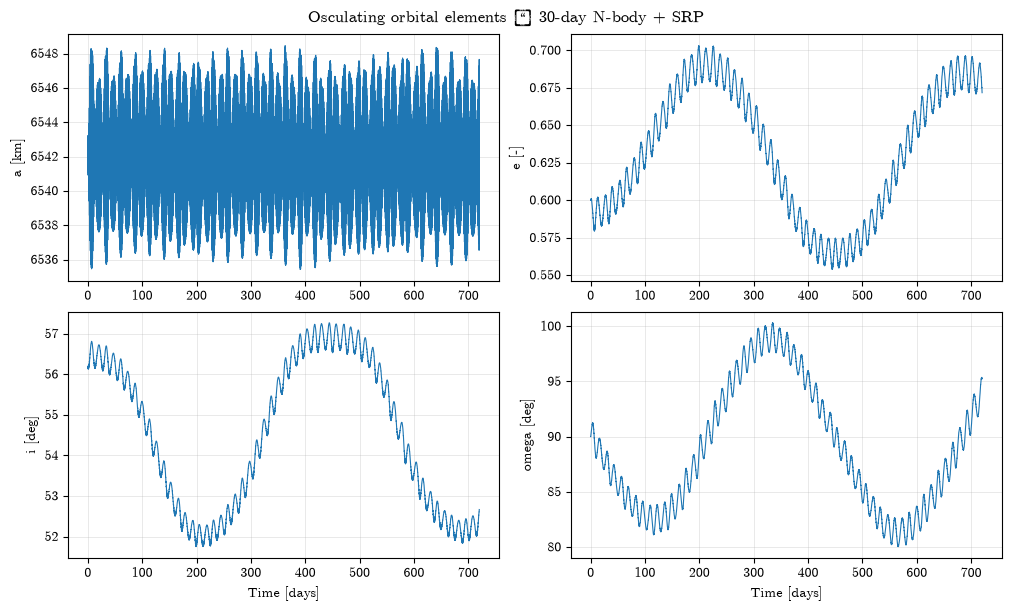

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6), constrained_layout=True)
fig.suptitle("Osculating orbital elements — 30-day N-body + SRP")

axes[0, 0].plot(t_days, coe[:, 0] / 1e3, lw=0.8)
axes[0, 0].set_ylabel("a [km]")

axes[0, 1].plot(t_days, coe[:, 1], lw=0.8)
axes[0, 1].set_ylabel("e [-]")

axes[1, 0].plot(t_days, coe[:, 2] * pnt.DEG, lw=0.8)
axes[1, 0].set_ylabel("i [deg]")
axes[1, 0].set_xlabel("Time [days]")

axes[1, 1].plot(t_days, coe[:, 4] * pnt.DEG, lw=0.8)
axes[1, 1].set_ylabel("omega [deg]")
axes[1, 1].set_xlabel("Time [days]")

for ax in axes.flat:
    ax.grid(True, lw=0.4, alpha=0.5)

plt.show()

## e–ω phase portrait (OP frame)

In the OP frame the frozen orbit librates around `(e=0.6, ω=90°)`, forming a
closed or near-closed loop.  Colour encodes elapsed time so the direction of
libration is visible.  The red star marks the Ely (2005) nominal frozen point.

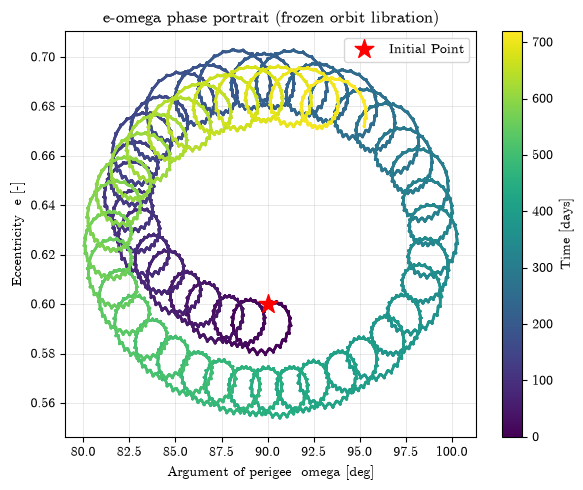

In [11]:
fig, ax = plt.subplots(figsize=(6, 5))

sc = ax.scatter(coe[:, 4] * pnt.DEG, coe[:, 1],
                c=t_days, cmap="viridis", s=4, lw=0, zorder=3)
ax.plot(coe[:, 4] * pnt.DEG, coe[:, 1],
        lw=0.5, color="steelblue", alpha=0.35, zorder=2)

ax.scatter([90.0], [0.6], marker="*", s=200, color="red",
           zorder=5, label="Initial Point")

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Time [days]")

ax.set_xlabel("Argument of perigee  omega [deg]")
ax.set_ylabel("Eccentricity  e [-]")
ax.set_title("e-omega phase portrait (frozen orbit libration)")
ax.legend()
ax.grid(True, lw=0.4, alpha=0.5)
plt.tight_layout()
plt.show()